In [1]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm

In [2]:
from audio_classification_playground.vox_profile.emotion.wavlm_emotion import WavLMWrapper
from audio_classification_playground.vox_profile.emotion.whisper_emotion import WhisperWrapper

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
# Load model from Huggingface
model = WavLMWrapper.from_pretrained("tiantiaf/wavlm-large-categorical-emotion").to(device)
model = model.eval()

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

model = WhisperWrapper.from_pretrained("tiantiaf/whisper-large-v3-msp-podcast-emotion").to(device)
model = model.eval()

Some weights of WhisperModel were not initialized from the model checkpoint at openai/whisper-large-v3 and are newly initialized because the shapes did not match:
- encoder.embed_positions.weight: found shape torch.Size([1500, 1280]) in the checkpoint and torch.Size([750, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# Label List
emotion_list = [
    'Anger', 
    'Contempt', 
    'Disgust', 
    'Fear', 
    'Happiness', 
    'Neutral', 
    'Sadness', 
    'Surprise', 
    'Other'
]
len(emotion_list)

9

In [6]:
import librosa
import torch
import torch.nn.functional as F
SR = 16_000
WINDOW_SEC = 3.0
HOP_SEC = 1.0
BATCH_SIZE = 20
window_samples = int(WINDOW_SEC * SR)   # 56,000
hop_samples = int(HOP_SEC * SR)         # 16,000

In [7]:
audio_path = "/workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3"
audio_path = "/workspace/tmp_data/jamespiper-2026-2-9__14-44-54.mp3"
audio_path = "/workspace/tmp_data/robbiestaniforth-2026-2-9__14-44-54.mp3"
audio,_ = librosa.load(audio_path, sr=SR, mono=True)

In [8]:
audio.shape[0]/SR/60

74.51740625000001

In [9]:
# 2. Convert to tensor
audio_t = torch.from_numpy(audio).float()
# 3. Pad so the last partial window isn't silently dropped
remainder = (len(audio_t) - window_samples) % hop_samples
if remainder != 0:
    pad_needed = hop_samples - remainder
    audio_t = F.pad(audio_t, (0, pad_needed))
# 4. Unfold into overlapping windows  →  [N, window_samples]
#    unfold(dim, size, step) returns a view — no copy
windows = audio_t.unfold(0, window_samples, hop_samples)


In [10]:
all_predicted = []
all_arousal   = []
all_valence   = []
all_dominance = []

for i in tqdm(range(0, len(windows), BATCH_SIZE)):
    batch = windows[i : i + BATCH_SIZE].to(device)
    with torch.no_grad():
        predicted, detailed_predicted, arousal, valence, dominance = model(batch, return_feature=False)
    all_predicted.append(predicted.cpu())
    all_arousal.append(arousal.cpu())
    all_valence.append(valence.cpu())
    all_dominance.append(dominance.cpu())

# single concat → [N, 9], [N, 1], [N, 1], [N, 1]
all_predicted = torch.cat(all_predicted)   # logits
all_arousal   = torch.cat(all_arousal).squeeze(-1)
all_valence   = torch.cat(all_valence).squeeze(-1)
all_dominance = torch.cat(all_dominance).squeeze(-1)

# softmax over the emotion logits
emotion_probs = F.softmax(all_predicted, dim=-1)   # [N, 9]

  0%|          | 0/224 [00:00<?, ?it/s]

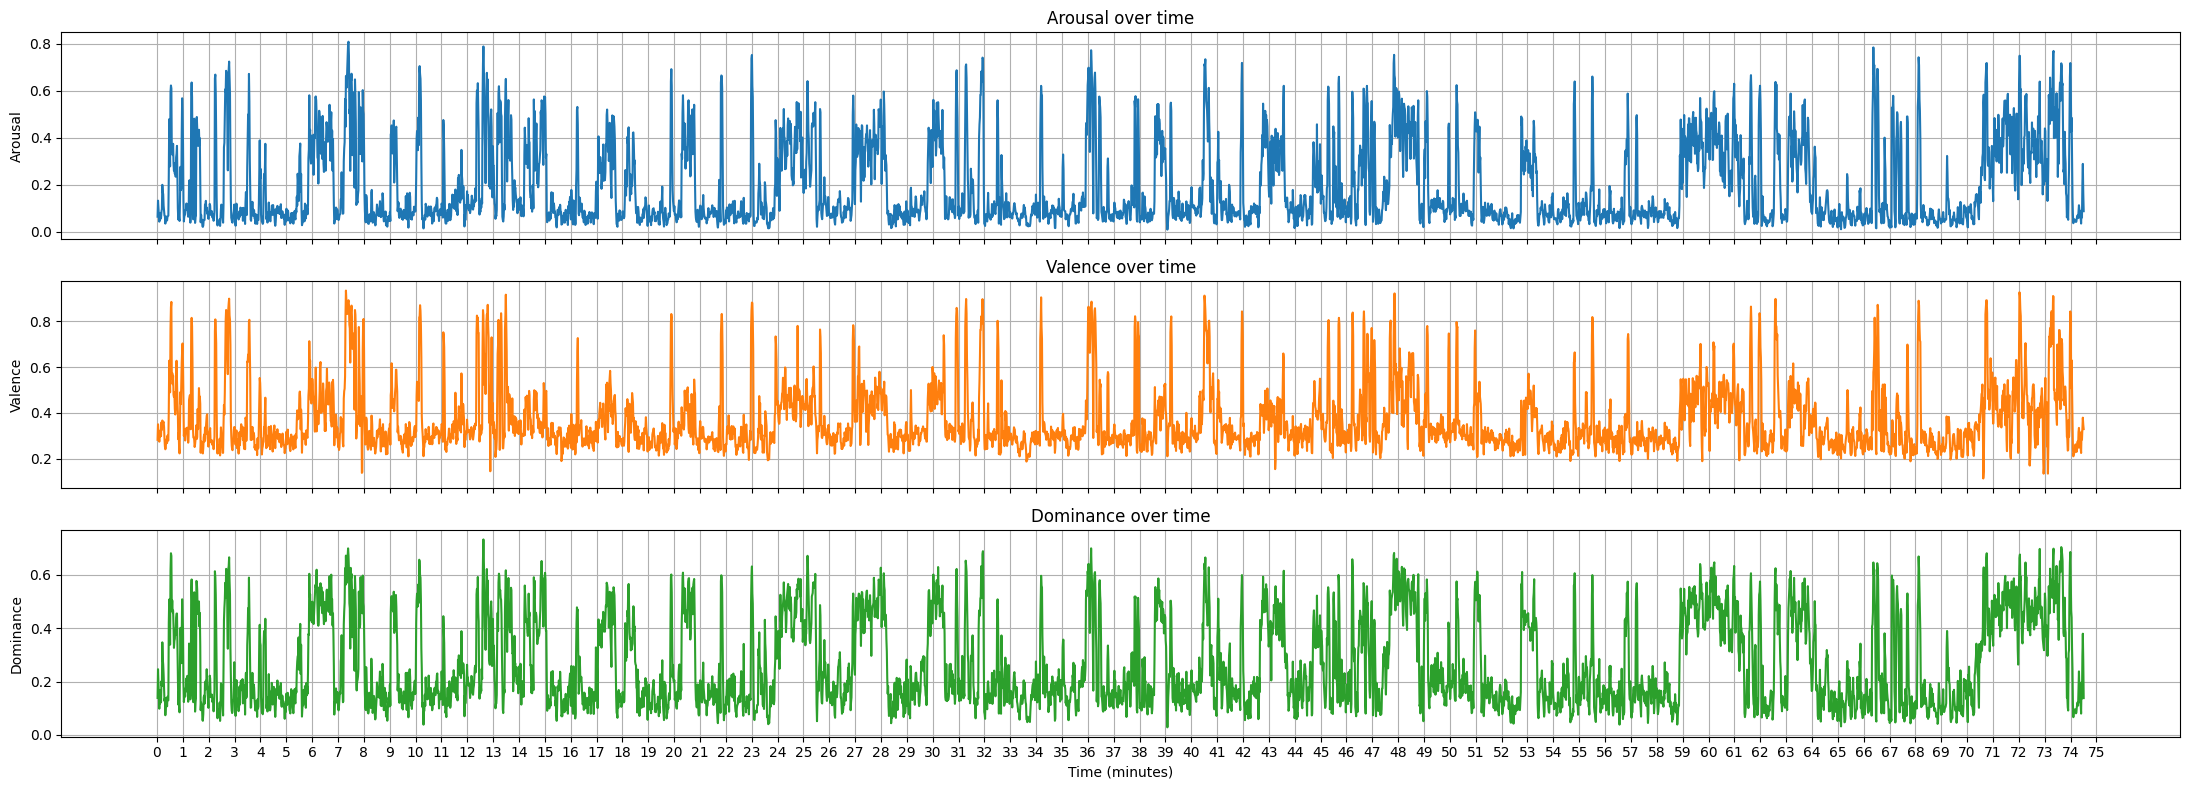

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Compute time axis for center of each window, in seconds first
num_windows = len(all_arousal)
window_centers_sec = np.arange(num_windows) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60.0

fig, axs = plt.subplots(3, 1, figsize=(22, 8), sharex=True)  # Widens the figure more

# Set major ticks at every minute (floor to closest integer min, up to last min)
time_min_max = window_centers_min[-1]
minute_ticks = np.arange(0, time_min_max + 1, 1)
axs[-1].set_xticks(minute_ticks)

axs[0].plot(window_centers_min, all_arousal, label="Arousal", color="tab:blue")
axs[0].set_ylabel("Arousal")
axs[0].set_title("Arousal over time")
axs[0].grid(True)
axs[0].set_xticks(minute_ticks)
axs[0].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[1].plot(window_centers_min, all_valence, label="Valence", color="tab:orange")
axs[1].set_ylabel("Valence")
axs[1].set_title("Valence over time")
axs[1].grid(True)
axs[1].set_xticks(minute_ticks)
axs[1].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[2].plot(window_centers_min, all_dominance, label="Dominance", color="tab:green")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_ylabel("Dominance")
axs[2].set_title("Dominance over time")
axs[2].grid(True)
axs[2].set_xticks(minute_ticks)
axs[2].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

# Format the x-axis as integer minutes
axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

time_sec = np.arange(len(emotion_probs)) * HOP_SEC
time_min = time_sec / 60.0

def format_min_tick(x, _):
    """Display as M:SS"""
    m, s = divmod(int(x * 60), 60)
    return f"{m}:{s:02d}"

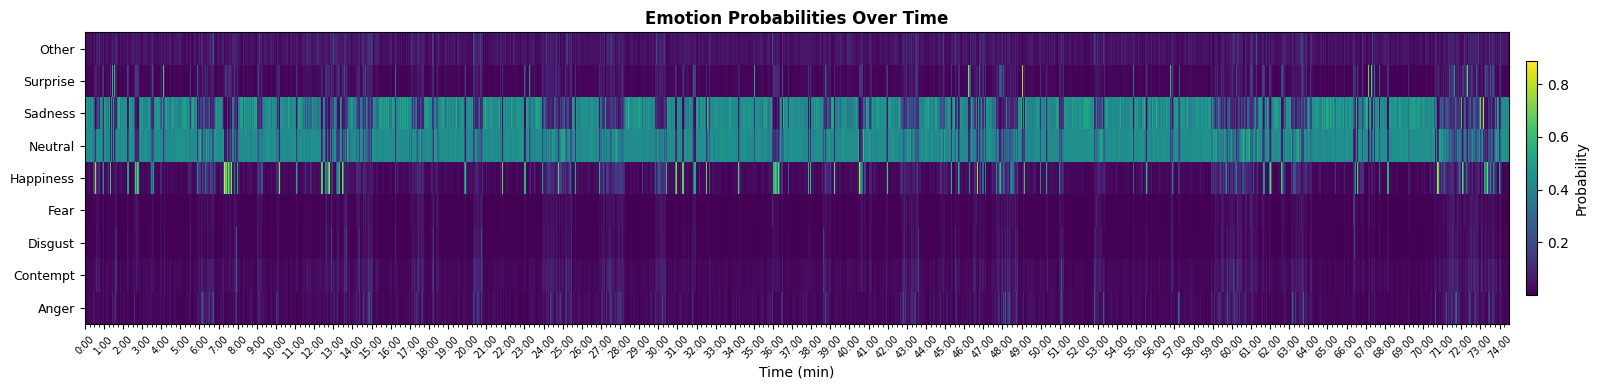

In [13]:
fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(
    emotion_probs.numpy().T,
    aspect="auto",
    interpolation="none",
    origin="lower",
    cmap="viridis",
    extent=[time_min[0], time_min[-1], -0.5, len(emotion_list) - 0.5],
)
ax.set_yticks(range(len(emotion_list)))
ax.set_yticklabels(emotion_list, fontsize=9)
ax.set_xlabel("Time (min)", fontsize=10)
ax.set_title("Emotion Probabilities Over Time", fontsize=12, fontweight="bold")

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))      # major every 1 min
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))   # minor every 15 sec
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_min_tick))
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)

fig.colorbar(im, ax=ax, label="Probability", shrink=0.8, pad=0.01)
plt.tight_layout()
plt.show()

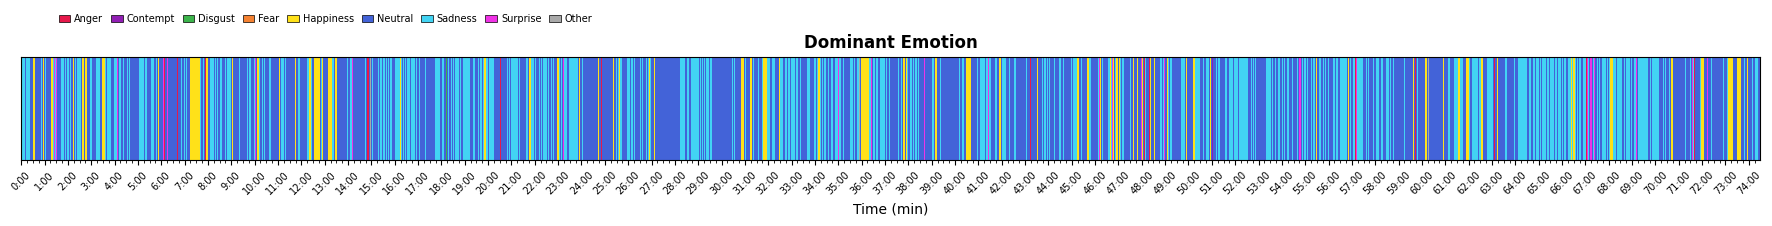

In [14]:
dominant_idx = emotion_probs.argmax(dim=-1).numpy()

# hand-picked distinct colors for 9 emotions — better than tab10 for adjacent bands
emotion_colors = [
    "#e6194b",  # Anger – red
    "#911eb4",  # Contempt – purple
    "#3cb44b",  # Disgust – green
    "#f58231",  # Fear – orange
    "#ffe119",  # Happiness – yellow
    "#4363d8",  # Neutral – blue
    "#42d4f4",  # Sadness – cyan
    "#f032e6",  # Surprise – magenta
    "#a9a9a9",  # Other – grey
]
from matplotlib.colors import ListedColormap
cmap_emo = ListedColormap(emotion_colors)

fig, ax = plt.subplots(figsize=(18, 3))

# draw as a colored bar, one pixel per window
ax.imshow(
    dominant_idx[None, :],
    aspect="auto",
    interpolation="nearest",
    cmap=cmap_emo,
    vmin=0,
    vmax=len(emotion_list) - 1,
    extent=[time_min[0], time_min[-1], 0, 1],
)
ax.set_yticks([])

# dense minute-level x ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_min_tick))
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)

ax.set_xlabel("Time (min)", fontsize=10)
ax.set_title("Dominant Emotion", fontsize=12, fontweight="bold")

# legend with matching colors — horizontal, compact
patches = [mpatches.Patch(facecolor=c, edgecolor="black", linewidth=0.5, label=e)
           for c, e in zip(emotion_colors, emotion_list)]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=len(emotion_list), fontsize=7, frameon=False,
          handlelength=1.2, handletextpad=0.4, columnspacing=0.8)
# Move legend to the top, right above the plot, as a horizontal band to avoid overlap
ax.legend(
    handles=patches,
    loc="upper center",
    bbox_to_anchor=(0.175, 1.5),
    ncol=len(emotion_list),
    fontsize=7,
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    columnspacing=0.8
)

plt.tight_layout()
plt.show()

In [15]:
# Define the time axis corresponding to each probability frame
# Assume probs_np.shape[0] is number of frames, and duration_sec and total_frames are known or can be inferred
# Common way: linspace from 0 to audio duration, matching probs_np.shape[0]


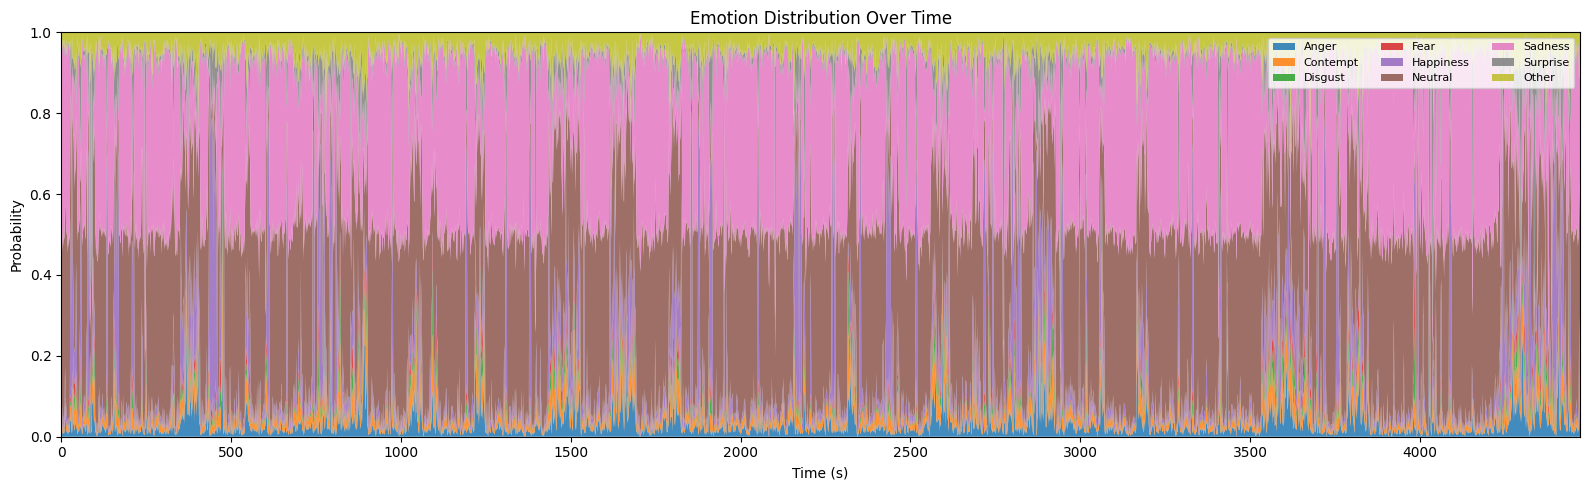

In [16]:
fig, ax = plt.subplots(figsize=(16, 5))
probs_np = emotion_probs.numpy()  # [N, 9]

duration_sec = len(audio) / SR  # where `audio` is the waveform and `sr` is the sample rate
num_frames = probs_np.shape[0]
time_axis = np.linspace(0, duration_sec, num_frames)

ax.stackplot(
    time_axis,
    probs_np.T,                    # each row is one emotion's time series
    labels=emotion_list,
    alpha=0.85,
)
ax.set_xlim(time_axis[0], time_axis[-1])
ax.set_ylim(0, 1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Probability")


ax.set_title("Emotion Distribution Over Time")
ax.legend(loc="upper right", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

/workspace/tmp/ipykernel_1928478/1647058969.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(emotion_list))


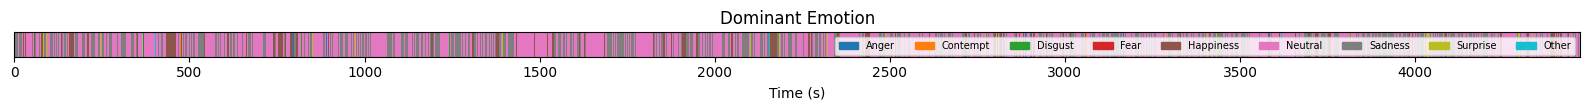

In [17]:
dominant_idx = emotion_probs.argmax(dim=-1).numpy()  # [N]

cmap = plt.cm.get_cmap("tab10", len(emotion_list))
fig, ax = plt.subplots(figsize=(16, 1.2))
ax.imshow(
    dominant_idx[None, :],          # [1, N]
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0, vmax=len(emotion_list) - 1,
    extent=[time_axis[0], time_axis[-1], 0, 1],
)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title("Dominant Emotion")

# legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=cmap(i), label=e) for i, e in enumerate(emotion_list)]
ax.legend(handles=patches, loc="upper right", fontsize=7, ncol=len(emotion_list))
plt.tight_layout()
plt.show()

/workspace/tmp/ipykernel_1928478/661700210.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_dom = plt.cm.get_cmap("tab10", len(emotion_list))


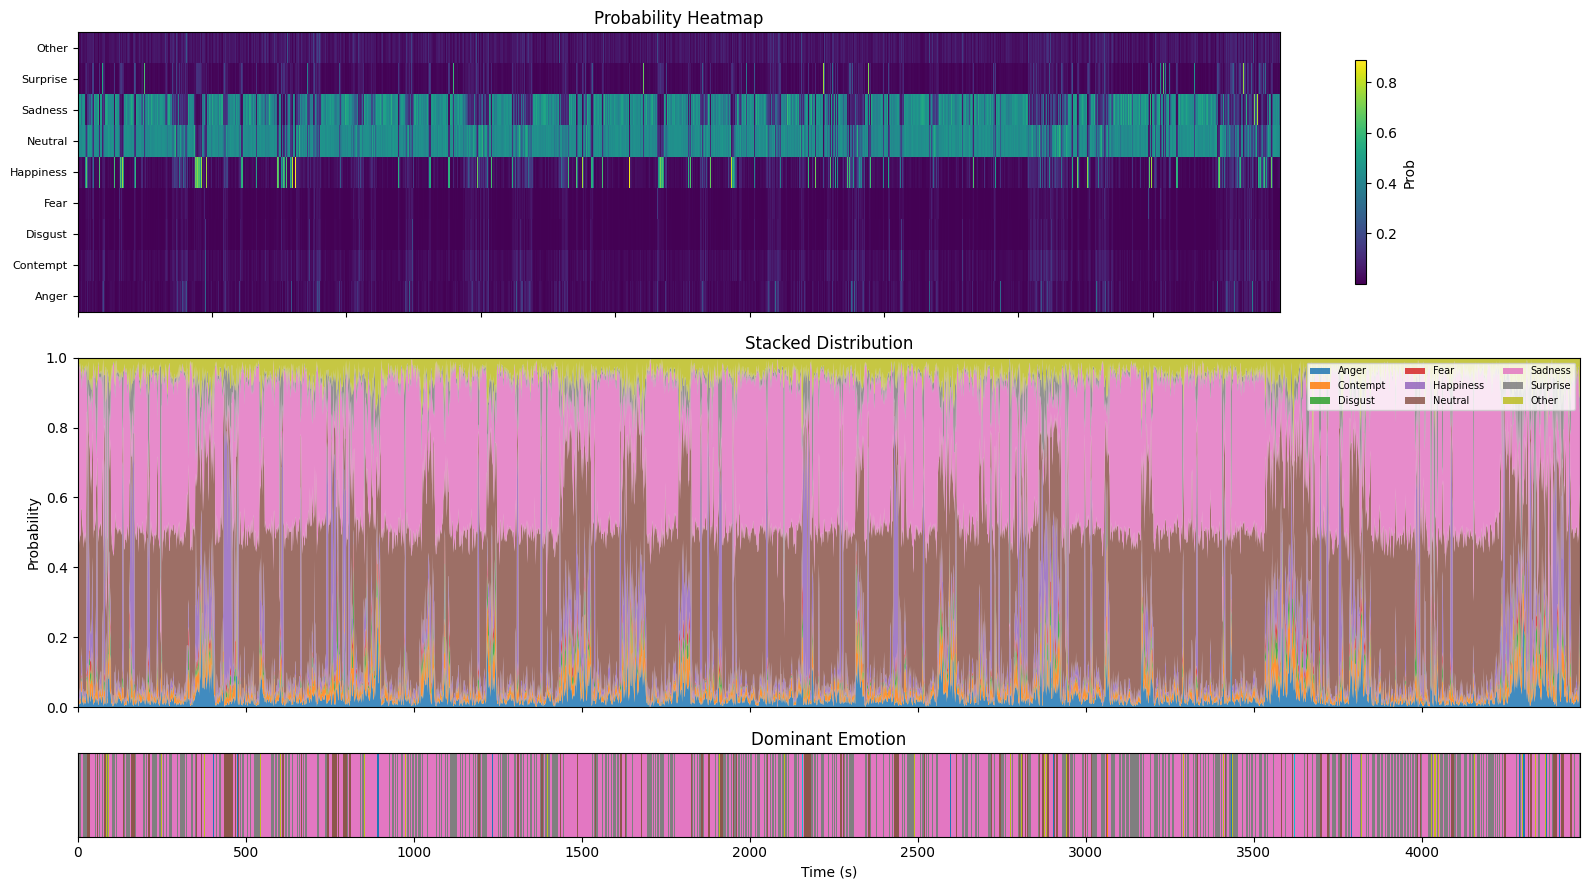

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True,
                         gridspec_kw={"height_ratios": [4, 5, 1.2]})

# -- heatmap --
im = axes[0].imshow(emotion_probs.numpy().T, aspect="auto", interpolation="none",
                    origin="lower", cmap="viridis",
                    extent=[time_axis[0], time_axis[-1], -0.5, len(emotion_list)-0.5])
axes[0].set_yticks(range(len(emotion_list)))
axes[0].set_yticklabels(emotion_list, fontsize=8)
axes[0].set_title("Probability Heatmap")
fig.colorbar(im, ax=axes[0], shrink=0.8, label="Prob")

# -- stacked area --
axes[1].stackplot(time_axis, emotion_probs.numpy().T, labels=emotion_list, alpha=0.85)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Probability")
axes[1].set_title("Stacked Distribution")
axes[1].legend(loc="upper right", fontsize=7, ncol=3)

# -- dominant strip --
cmap_dom = plt.cm.get_cmap("tab10", len(emotion_list))
axes[2].imshow(dominant_idx[None, :], aspect="auto", interpolation="nearest",
               cmap=cmap_dom, vmin=0, vmax=len(emotion_list)-1,
               extent=[time_axis[0], time_axis[-1], 0, 1])
axes[2].set_yticks([])
axes[2].set_title("Dominant Emotion")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [19]:
# --- Cell 1: class partition + cached summary stats ---
import numpy as np

probs_np = emotion_probs.numpy()           # [N, 9]
N, K = probs_np.shape

UNINTERESTING = {"Neutral", "Other"}
interesting_idx    = [i for i, e in enumerate(emotion_list) if e not in UNINTERESTING]
uninteresting_idx  = [i for i, e in enumerate(emotion_list) if e in UNINTERESTING]
interesting_labels = [emotion_list[i] for i in interesting_idx]

dominant_idx = probs_np.argmax(axis=-1)
top1_prob    = probs_np.max(axis=-1)
sorted_p     = np.sort(probs_np, axis=-1)
margin       = sorted_p[:, -1] - sorted_p[:, -2]
is_interesting_top1 = np.isin(dominant_idx, interesting_idx)

# canonical time axis (window centers)
window_centers_sec = np.arange(N) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60.0

print(f"windows: {N}   duration: {window_centers_sec[-1]/60:.1f} min")
print(f"argmax is an interesting class in "
      f"{is_interesting_top1.sum()} / {N} windows ({100*is_interesting_top1.mean():.1f}%)")
print(f"top1_prob:   mean={top1_prob.mean():.2f}, median={np.median(top1_prob):.2f}, "
      f"min={top1_prob.min():.2f}, max={top1_prob.max():.2f}")
print(f"margin:      mean={margin.mean():.2f},   median={np.median(margin):.2f}, "
      f"min={margin.min():.2f},   max={margin.max():.2f}")

windows: 4470   duration: 74.5 min
argmax is an interesting class in 2067 / 4470 windows (46.2%)
top1_prob:   mean=0.44, median=0.45, min=0.16, max=0.89
margin:      mean=0.11,   median=0.05, min=0.00,   max=0.84


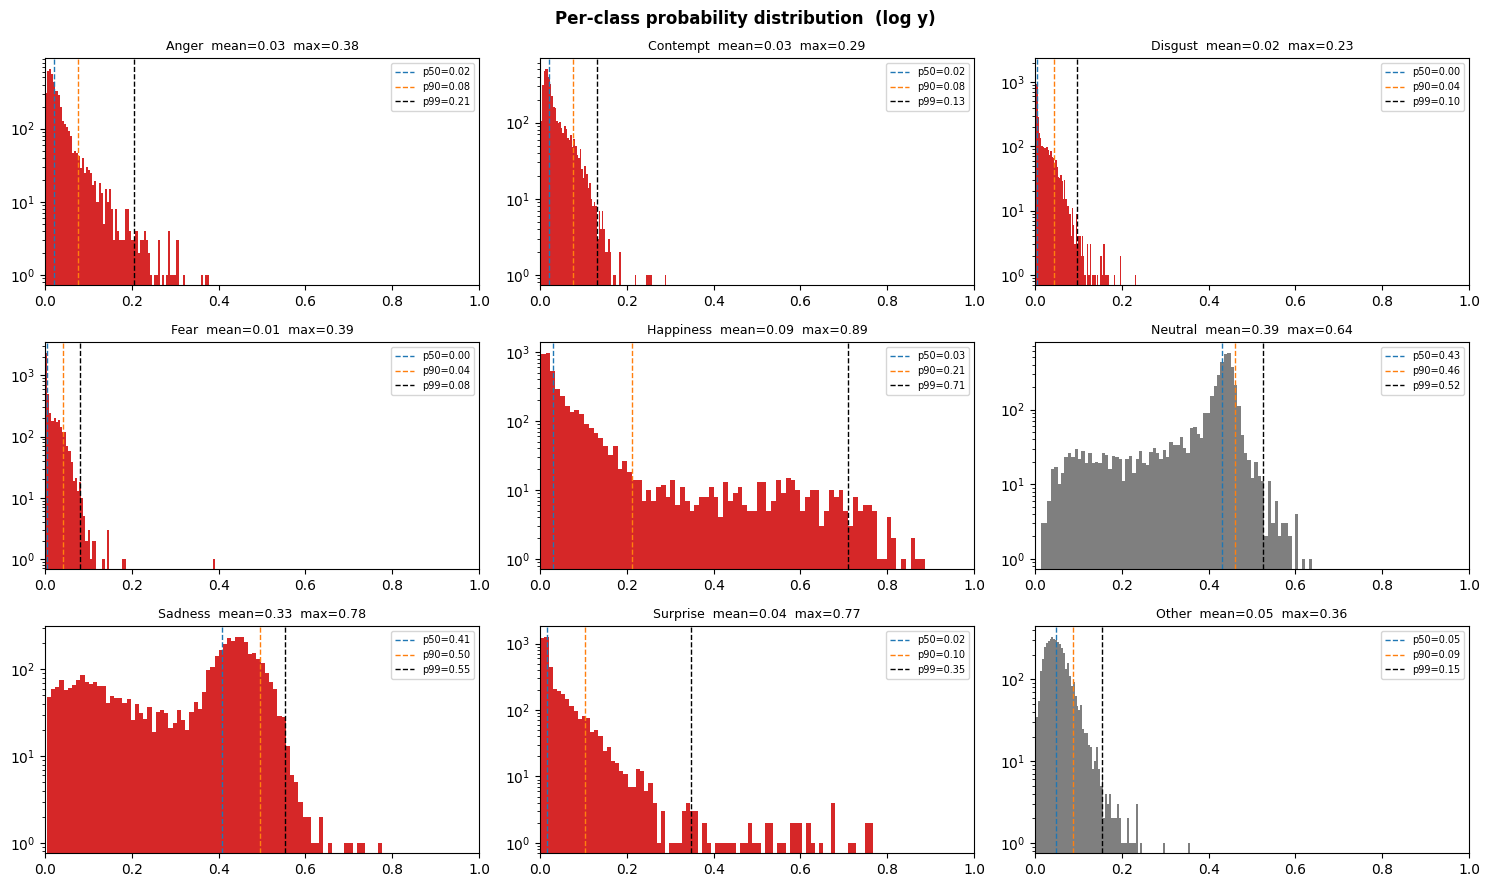

In [20]:
# --- Cell 2: per-class probability baselines (log y, with quantile lines) ---
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for i, label in enumerate(emotion_list):
    ax = axes[i // 3, i % 3]
    vals = probs_np[:, i]
    ax.hist(vals, bins=80, log=True,
            color=("tab:gray" if label in UNINTERESTING else "tab:red"))
    q50, q90, q99 = np.quantile(vals, [0.5, 0.9, 0.99])
    for q, c, lbl in [(q50, "tab:blue", "p50"),
                      (q90, "tab:orange", "p90"),
                      (q99, "black", "p99")]:
        ax.axvline(q, color=c, linestyle="--", linewidth=1, label=f"{lbl}={q:.2f}")
    ax.set_title(f"{label}  mean={vals.mean():.2f}  max={vals.max():.2f}", fontsize=9)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)
fig.suptitle("Per-class probability distribution  (log y)", fontweight="bold")
plt.tight_layout(); plt.show()

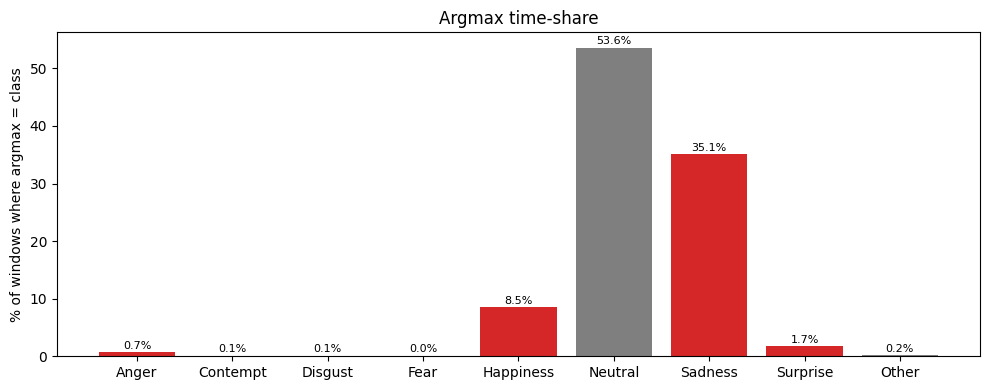

In [21]:
# --- Cell 3: argmax time-share per class ---
counts = np.bincount(dominant_idx, minlength=K)
shares = counts / N

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tab:gray" if e in UNINTERESTING else "tab:red" for e in emotion_list]
bars = ax.bar(emotion_list, 100 * shares, color=colors)
for b, s in zip(bars, shares):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{100*s:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("% of windows where argmax = class")
ax.set_title("Argmax time-share")
plt.tight_layout(); plt.show()

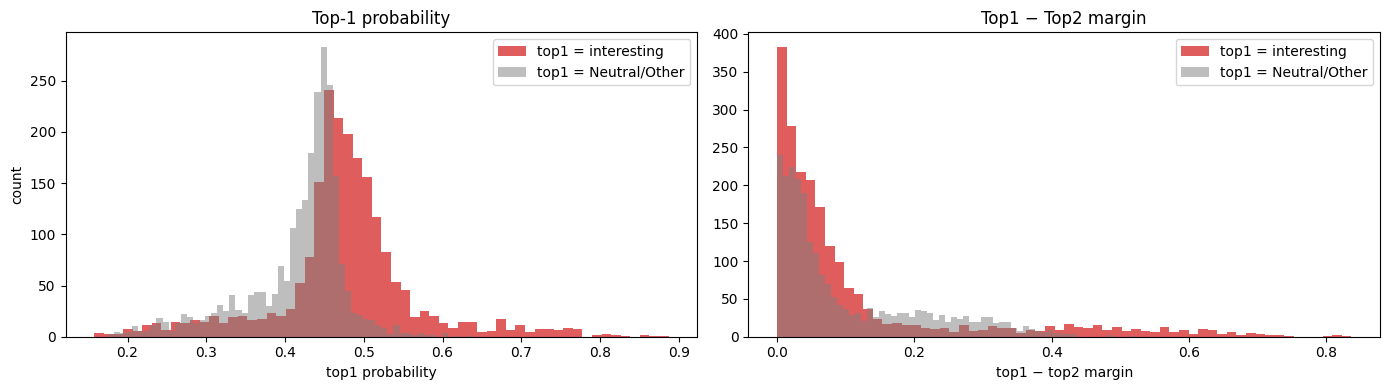

In [22]:
# --- Cell 4: top1 prob and top1-top2 margin, split by 'interesting top1' ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(top1_prob[is_interesting_top1],  bins=60, alpha=0.75,
             label="top1 = interesting", color="tab:red")
axes[0].hist(top1_prob[~is_interesting_top1], bins=60, alpha=0.5,
             label="top1 = Neutral/Other", color="tab:gray")
axes[0].set_xlabel("top1 probability"); axes[0].set_ylabel("count"); axes[0].legend()
axes[0].set_title("Top-1 probability")

axes[1].hist(margin[is_interesting_top1],  bins=60, alpha=0.75,
             label="top1 = interesting", color="tab:red")
axes[1].hist(margin[~is_interesting_top1], bins=60, alpha=0.5,
             label="top1 = Neutral/Other", color="tab:gray")
axes[1].set_xlabel("top1 − top2 margin"); axes[1].legend()
axes[1].set_title("Top1 − Top2 margin")

plt.tight_layout(); plt.show()

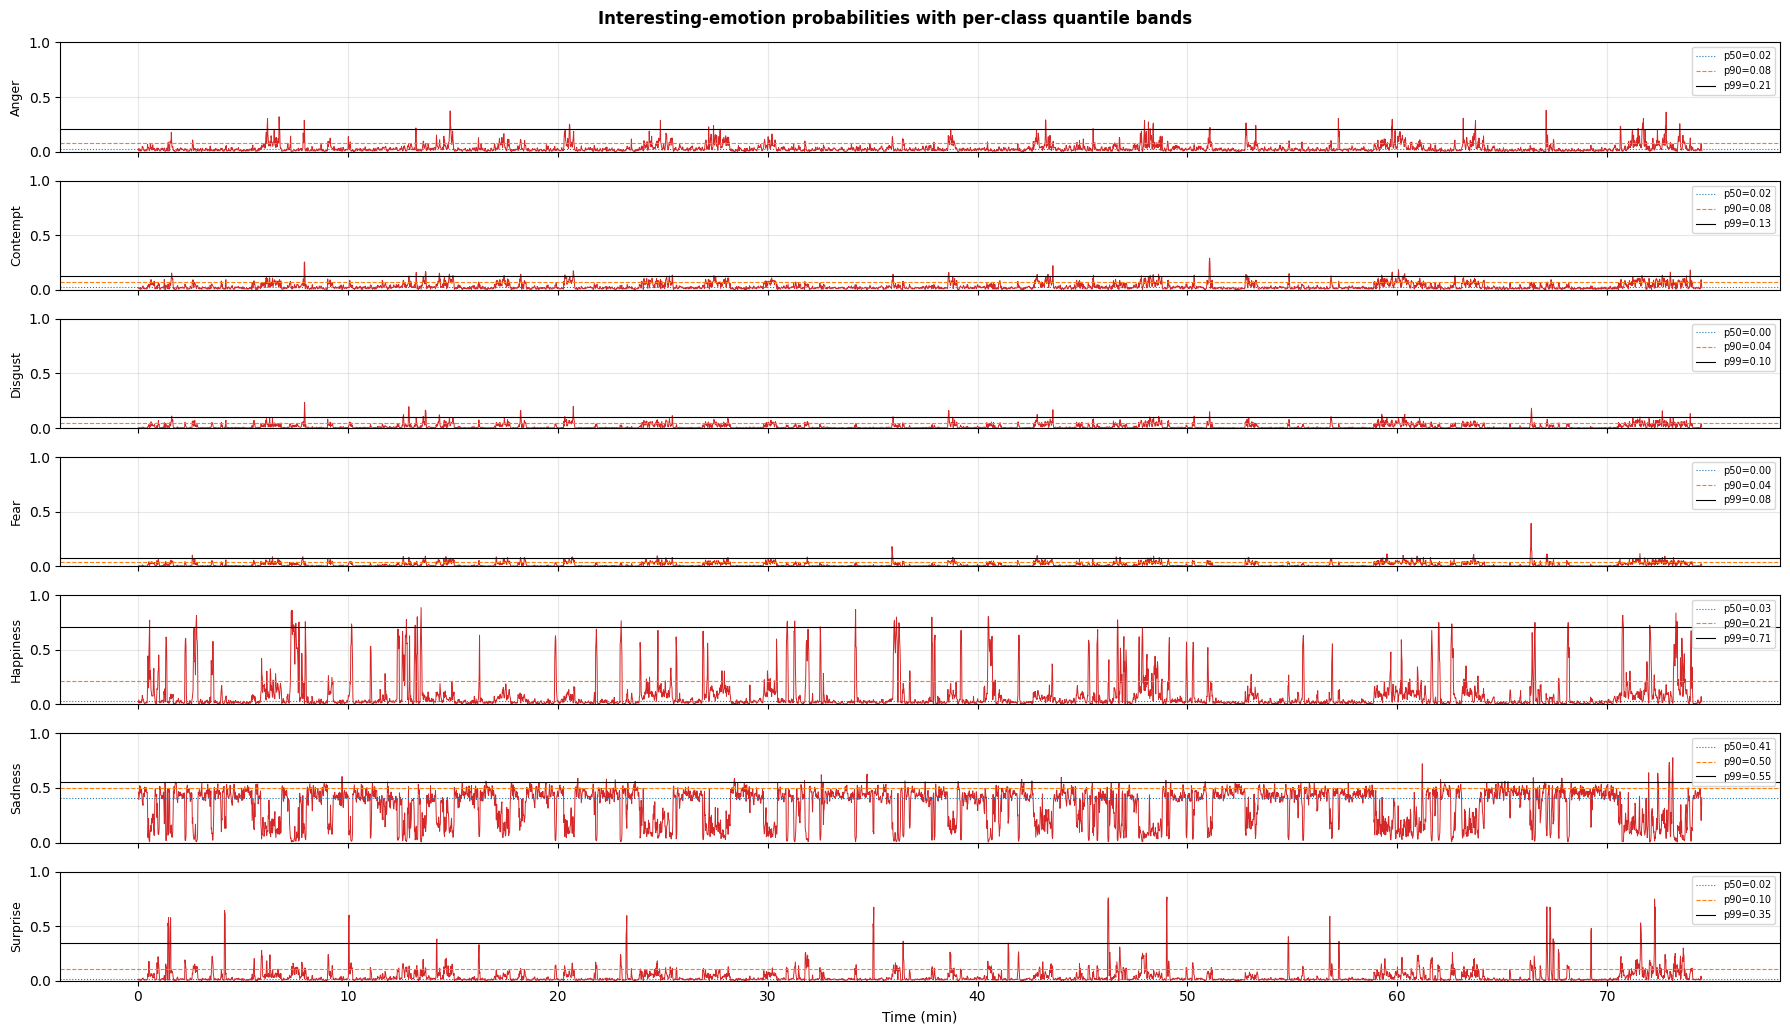

In [23]:
# --- Cell 5: per-emotion line plot with self-quantile reference lines ---
fig, axes = plt.subplots(len(interesting_idx), 1,
                         figsize=(18, 1.5 * len(interesting_idx)), sharex=True)

for ax, ci, lbl in zip(axes, interesting_idx, interesting_labels):
    vals = probs_np[:, ci]
    q50, q90, q99 = np.quantile(vals, [0.5, 0.9, 0.99])
    ax.plot(window_centers_min, vals, color="tab:red", linewidth=0.7)
    ax.axhline(q50, color="tab:blue",   linestyle=":",  linewidth=0.8, label=f"p50={q50:.2f}")
    ax.axhline(q90, color="tab:orange", linestyle="--", linewidth=0.8, label=f"p90={q90:.2f}")
    ax.axhline(q99, color="black",      linestyle="-",  linewidth=0.8, label=f"p99={q99:.2f}")
    ax.set_ylabel(lbl, fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Time (min)")
fig.suptitle("Interesting-emotion probabilities with per-class quantile bands",
             fontweight="bold")
plt.tight_layout(); plt.show()

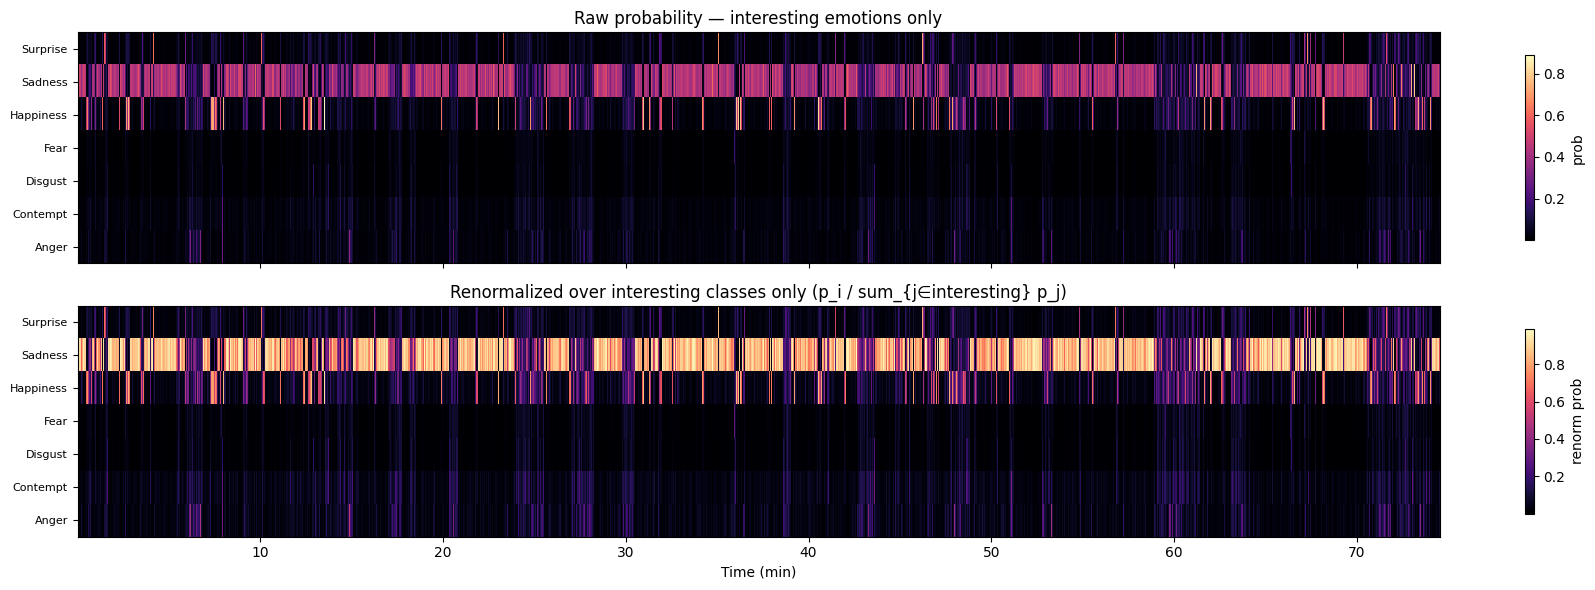

In [24]:
# --- Cell 6: suppressed-Neutral/Other heatmap (raw + renormalized over 7 classes) ---
interesting_probs = probs_np[:, interesting_idx]                       # [N, 7]
mass = interesting_probs.sum(axis=-1, keepdims=True)
renorm = np.where(mass > 1e-9, interesting_probs / mass, 0.0)          # [N, 7]

fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

im0 = axes[0].imshow(interesting_probs.T, aspect="auto", interpolation="none",
                     origin="lower", cmap="magma",
                     extent=[window_centers_min[0], window_centers_min[-1],
                             -0.5, len(interesting_idx)-0.5])
axes[0].set_yticks(range(len(interesting_idx)))
axes[0].set_yticklabels(interesting_labels, fontsize=8)
axes[0].set_title("Raw probability — interesting emotions only")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="prob")

im1 = axes[1].imshow(renorm.T, aspect="auto", interpolation="none",
                     origin="lower", cmap="magma",
                     extent=[window_centers_min[0], window_centers_min[-1],
                             -0.5, len(interesting_idx)-0.5])
axes[1].set_yticks(range(len(interesting_idx)))
axes[1].set_yticklabels(interesting_labels, fontsize=8)
axes[1].set_title("Renormalized over interesting classes only "
                  "(p_i / sum_{j∈interesting} p_j)")
axes[1].set_xlabel("Time (min)")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="renorm prob")

plt.tight_layout(); plt.show()

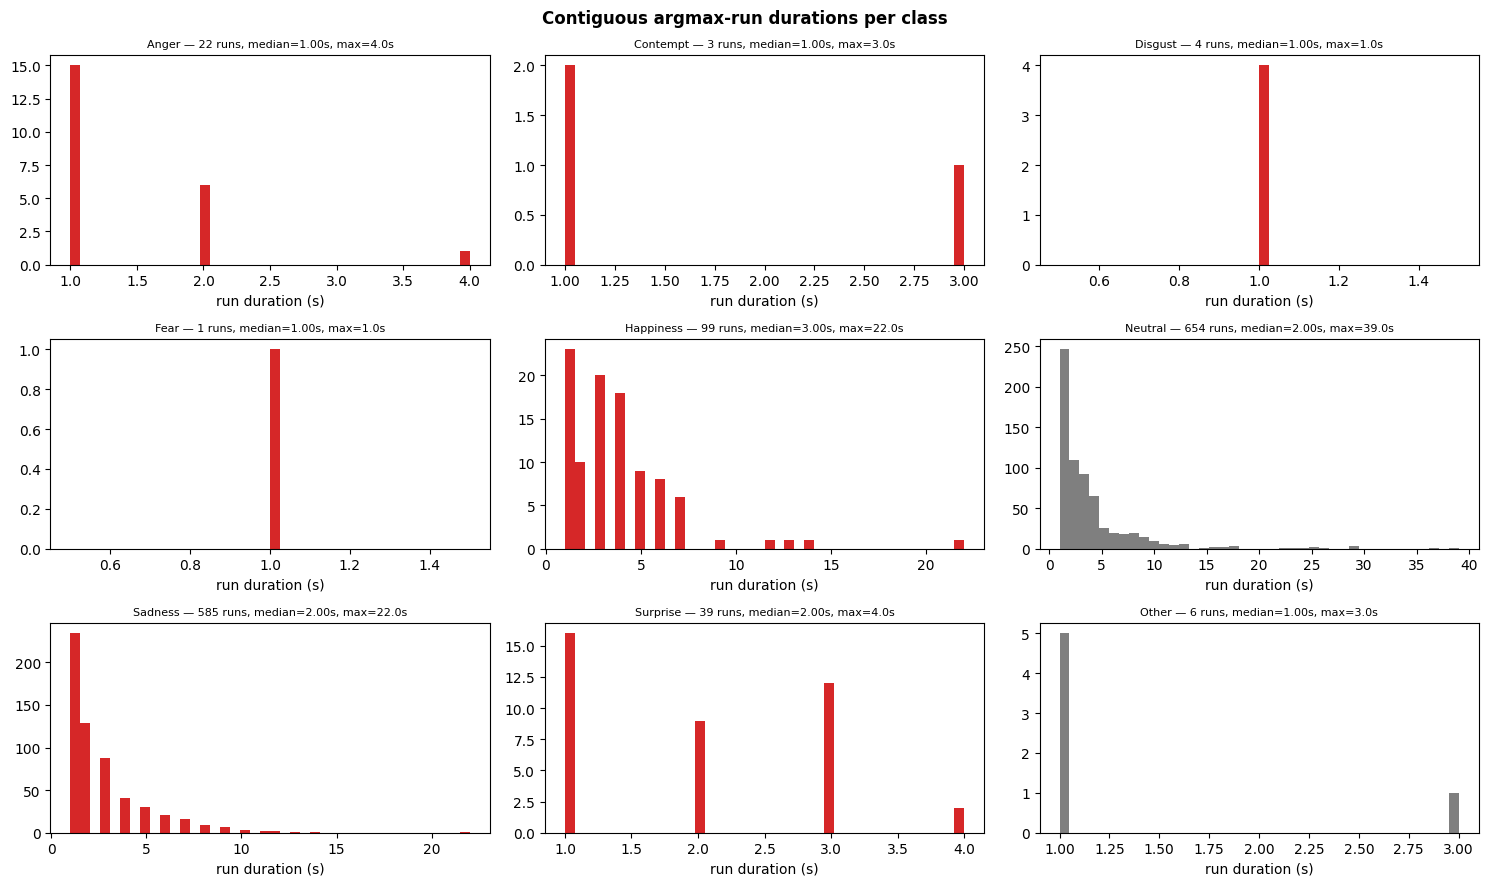

In [25]:
# --- Cell 7: run-length distribution of argmax, per class ---
def run_lengths(arr):
    if len(arr) == 0:
        return np.array([]), np.array([])
    bnd = np.concatenate([[0], np.where(np.diff(arr) != 0)[0] + 1, [len(arr)]])
    return arr[bnd[:-1]], np.diff(bnd)

run_vals, run_lens = run_lengths(dominant_idx)
run_durs_sec = run_lens * HOP_SEC

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for i, label in enumerate(emotion_list):
    ax = axes[i // 3, i % 3]
    durs = run_durs_sec[run_vals == i]
    color = "tab:gray" if label in UNINTERESTING else "tab:red"
    if len(durs) == 0:
        ax.set_title(f"{label} — no runs", fontsize=9)
        ax.set_axis_off()
        continue
    ax.hist(durs, bins=40, color=color)
    ax.set_title(f"{label} — {len(durs)} runs, "
                 f"median={np.median(durs):.2f}s, max={durs.max():.1f}s", fontsize=8)
    ax.set_xlabel("run duration (s)")
fig.suptitle("Contiguous argmax-run durations per class", fontweight="bold")
plt.tight_layout(); plt.show()

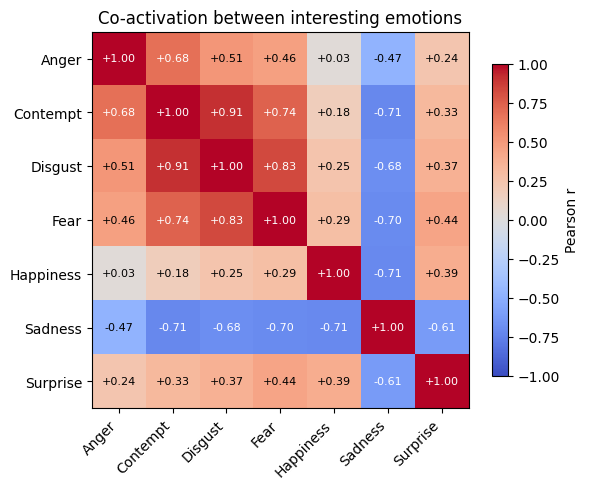

In [26]:
# --- Cell 8: pairwise correlation between interesting-class probabilities ---
import pandas as pd

df = pd.DataFrame(interesting_probs, columns=interesting_labels)
corr = df.corr(method="pearson").values

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(interesting_labels)))
ax.set_xticklabels(interesting_labels, rotation=45, ha="right")
ax.set_yticks(range(len(interesting_labels)))
ax.set_yticklabels(interesting_labels)
for i in range(len(interesting_labels)):
    for j in range(len(interesting_labels)):
        ax.text(j, i, f"{corr[i, j]:+.2f}", ha="center", va="center", fontsize=8,
                color="black" if abs(corr[i, j]) < 0.6 else "white")
fig.colorbar(im, shrink=0.8, label="Pearson r")
ax.set_title("Co-activation between interesting emotions")
plt.tight_layout(); plt.show()

# Continuation

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

probs_np = emotion_probs.detach().cpu().numpy()
logits_np = all_predicted.detach().cpu().numpy()

N, K = probs_np.shape
assert K == len(emotion_list), (K, len(emotion_list))

UNINTERESTING = {"Neutral", "Other"}
interesting_idx = [i for i, label in enumerate(emotion_list) if label not in UNINTERESTING]
uninteresting_idx = [i for i, label in enumerate(emotion_list) if label in UNINTERESTING]
interesting_labels = [emotion_list[i] for i in interesting_idx]

frame_start_sec = np.arange(N) * HOP_SEC
frame_end_sec = frame_start_sec + WINDOW_SEC
frame_center_sec = frame_start_sec + WINDOW_SEC / 2
frame_center_min = frame_center_sec / 60

top1_idx = probs_np.argmax(axis=1)
top1_prob = probs_np.max(axis=1)

sorted_idx = np.argsort(probs_np, axis=1)
top2_idx = sorted_idx[:, -2]
top2_prob = probs_np[np.arange(N), top2_idx]
top1_margin = top1_prob - top2_prob

interesting_probs = probs_np[:, interesting_idx]
interesting_mass = interesting_probs.sum(axis=1)
uninteresting_mass = probs_np[:, uninteresting_idx].sum(axis=1)

best_interesting_local_idx = interesting_probs.argmax(axis=1)
best_interesting_idx = np.array(interesting_idx)[best_interesting_local_idx]
best_interesting_prob = probs_np[np.arange(N), best_interesting_idx]

interesting_margin_vs_background = best_interesting_prob - probs_np[:, uninteresting_idx].max(axis=1)
is_top1_interesting = np.isin(top1_idx, interesting_idx)

entropy = -(probs_np * np.log(np.clip(probs_np, 1e-12, 1))).sum(axis=1)

print(f"frames: {N}")
print(f"audio duration from frames: {frame_end_sec[-1] / 60:.2f} min")
print(f"prob shape: {probs_np.shape}")
print(f"logit shape: {logits_np.shape}")
print()
print(f"top1 interesting frames: {is_top1_interesting.sum()} / {N} ({100 * is_top1_interesting.mean():.1f}%)")
print(f"interesting mass: median={np.median(interesting_mass):.3f}, p90={np.quantile(interesting_mass, 0.90):.3f}, max={interesting_mass.max():.3f}")
print(f"top1 probability: median={np.median(top1_prob):.3f}, p90={np.quantile(top1_prob, 0.90):.3f}, max={top1_prob.max():.3f}")
print(f"top1 margin: median={np.median(top1_margin):.3f}, p90={np.quantile(top1_margin, 0.90):.3f}, max={top1_margin.max():.3f}")
print(f"entropy: median={np.median(entropy):.3f}, p90={np.quantile(entropy, 0.90):.3f}")


frames: 4470
audio duration from frames: 74.53 min
prob shape: (4470, 9)
logit shape: (4470, 9)

top1 interesting frames: 2067 / 4470 (46.2%)
interesting mass: median=0.529, p90=0.722, max=0.980
top1 probability: median=0.450, p90=0.522, max=0.887
top1 margin: median=0.052, p90=0.304, max=0.837
entropy: median=1.259, p90=1.892


In [28]:
rows = []
for i, label in enumerate(emotion_list):
    vals = probs_np[:, i]
    argmax_mask = top1_idx == i
    rows.append({
        "label": label,
        "interesting": label not in UNINTERESTING,
        "mean_prob": vals.mean(),
        "p50": np.quantile(vals, 0.50),
        "p75": np.quantile(vals, 0.75),
        "p90": np.quantile(vals, 0.90),
        "p95": np.quantile(vals, 0.95),
        "p99": np.quantile(vals, 0.99),
        "max": vals.max(),
        "argmax_frames": int(argmax_mask.sum()),
        "argmax_share_pct": 100 * argmax_mask.mean(),
    })

class_stats = pd.DataFrame(rows).sort_values(["interesting", "argmax_share_pct"], ascending=[False, False])
display(class_stats)


,label,interesting,mean_prob,p50,p75,p90,p95,p99,max,argmax_frames,argmax_share_pct
6,Sadness,True,0.334969,0.406756,0.456362,0.495927,0.517205,0.553389,0.776813,1568,35.078300
4,Happiness,True,0.087877,0.029172,0.085418,0.210938,0.493302,0.710605,0.887042,380,8.501119
7,Surprise,True,0.042099,0.016927,0.048647,0.104507,0.144757,0.347344,0.767029,78,1.744966
0,Anger,True,0.033453,0.020511,0.037870,0.075672,0.109129,0.205841,0.378511,31,0.693512
1,Contempt,True,0.032887,0.021719,0.043632,0.075683,0.093405,0.130856,0.290785,5,0.111857
2,Disgust,True,0.015220,0.004565,0.021012,0.044882,0.059543,0.097495,0.233681,4,0.089485
3,Fear,True,0.014273,0.004619,0.021948,0.041771,0.052072,0.079477,0.392134,1,0.022371
5,Neutral,False,0.386761,0.431311,0.447290,0.460018,0.469841,0.524805,0.638009,2395,53.579418
8,Other,False,0.052460,0.047457,0.065840,0.088450,0.105891,0.154135,0.357510,8,0.178971


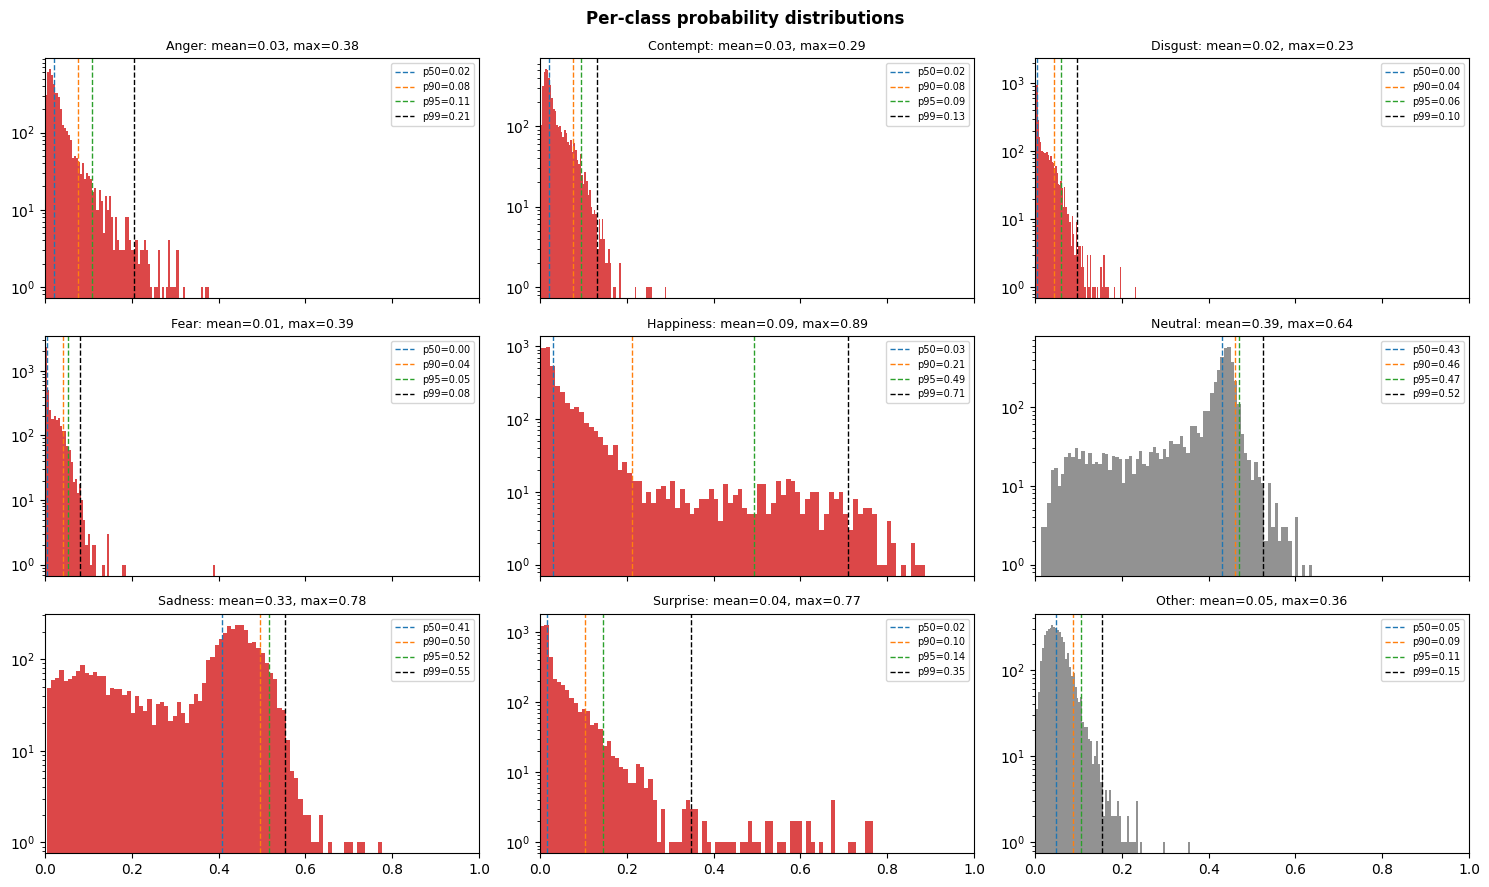

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)

for i, label in enumerate(emotion_list):
    ax = axes[i // 3, i % 3]
    vals = probs_np[:, i]
    color = "tab:gray" if label in UNINTERESTING else "tab:red"

    ax.hist(vals, bins=80, color=color, alpha=0.85, log=True)
    for q, name, line_color in [
        (0.50, "p50", "tab:blue"),
        (0.90, "p90", "tab:orange"),
        (0.95, "p95", "tab:green"),
        (0.99, "p99", "black"),
    ]:
        v = np.quantile(vals, q)
        ax.axvline(v, color=line_color, linestyle="--", linewidth=1, label=f"{name}={v:.2f}")

    ax.set_title(f"{label}: mean={vals.mean():.2f}, max={vals.max():.2f}", fontsize=9)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)

fig.suptitle("Per-class probability distributions", fontweight="bold")
plt.tight_layout()
plt.show()


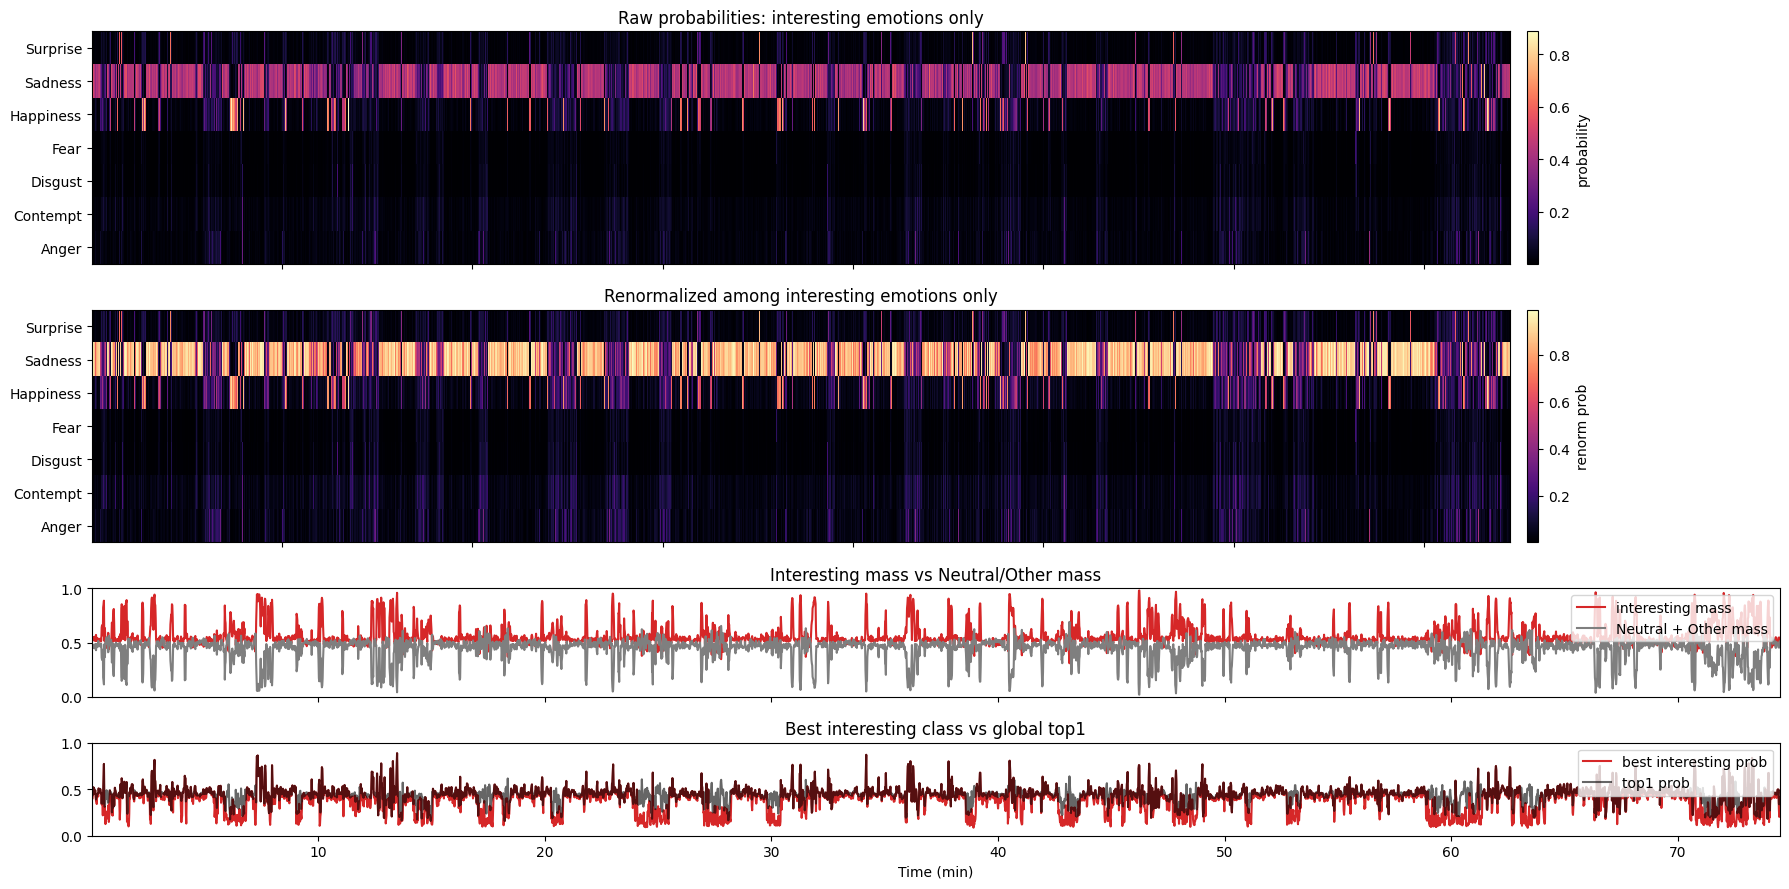

In [30]:
renorm_interesting_probs = interesting_probs / np.clip(interesting_mass[:, None], 1e-9, None)

fig, axes = plt.subplots(4, 1, figsize=(18, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 3, 1.4, 1.2]})

im0 = axes[0].imshow(
    interesting_probs.T,
    aspect="auto",
    interpolation="none",
    origin="lower",
    cmap="magma",
    extent=[frame_center_min[0], frame_center_min[-1], -0.5, len(interesting_labels) - 0.5],
)
axes[0].set_yticks(range(len(interesting_labels)))
axes[0].set_yticklabels(interesting_labels)
axes[0].set_title("Raw probabilities: interesting emotions only")
fig.colorbar(im0, ax=axes[0], label="probability", pad=0.01)

im1 = axes[1].imshow(
    renorm_interesting_probs.T,
    aspect="auto",
    interpolation="none",
    origin="lower",
    cmap="magma",
    extent=[frame_center_min[0], frame_center_min[-1], -0.5, len(interesting_labels) - 0.5],
)
axes[1].set_yticks(range(len(interesting_labels)))
axes[1].set_yticklabels(interesting_labels)
axes[1].set_title("Renormalized among interesting emotions only")
fig.colorbar(im1, ax=axes[1], label="renorm prob", pad=0.01)

axes[2].plot(frame_center_min, interesting_mass, color="tab:red", label="interesting mass")
axes[2].plot(frame_center_min, uninteresting_mass, color="tab:gray", label="Neutral + Other mass")
axes[2].set_ylim(0, 1)
axes[2].legend(loc="upper right")
axes[2].set_title("Interesting mass vs Neutral/Other mass")

axes[3].plot(frame_center_min, best_interesting_prob, color="tab:red", label="best interesting prob")
axes[3].plot(frame_center_min, top1_prob, color="black", alpha=0.6, label="top1 prob")
axes[3].set_ylim(0, 1)
axes[3].legend(loc="upper right")
axes[3].set_title("Best interesting class vs global top1")

axes[-1].set_xlabel("Time (min)")
plt.tight_layout()
plt.show()


In [31]:
def segments_from_mask(mask, min_duration_sec=1.0, merge_gap_sec=0.75):
    mask = np.asarray(mask, dtype=bool)
    bounds = np.concatenate([[0], np.where(np.diff(mask.astype(int)) != 0)[0] + 1, [len(mask)]])
    spans = [(s, e) for s, e in zip(bounds[:-1], bounds[1:]) if mask[s]]

    if not spans:
        return []

    max_gap_frames = int(np.ceil(merge_gap_sec / HOP_SEC))
    merged = [spans[0]]
    for s, e in spans[1:]:
        ps, pe = merged[-1]
        if s - pe <= max_gap_frames:
            merged[-1] = (ps, e)
        else:
            merged.append((s, e))

    min_frames = max(1, int(np.ceil(min_duration_sec / HOP_SEC)))
    return [(s, e) for s, e in merged if e - s >= min_frames]


def candidate_events(prob_thr=0.45, margin_thr=0.05, min_duration_sec=1.0, merge_gap_sec=0.75,
                     require_global_top1=True):
    events = []

    for class_idx, label in zip(interesting_idx, interesting_labels):
        class_prob = probs_np[:, class_idx]
        class_is_best_interesting = best_interesting_idx == class_idx

        mask = (
            class_is_best_interesting
            & (class_prob >= prob_thr)
            & (interesting_margin_vs_background >= margin_thr)
        )

        if require_global_top1:
            mask = mask & (top1_idx == class_idx)

        for s, e in segments_from_mask(mask, min_duration_sec=min_duration_sec, merge_gap_sec=merge_gap_sec):
            peak_rel = np.argmax(class_prob[s:e])
            peak_i = s + peak_rel

            top_at_peak = np.argsort(probs_np[peak_i])[::-1][:5]
            events.append({
                "label": label,
                "start_sec": frame_start_sec[s],
                "end_sec": frame_end_sec[e - 1],
                "duration_sec": frame_end_sec[e - 1] - frame_start_sec[s],
                "start_min": frame_start_sec[s] / 60,
                "end_min": frame_end_sec[e - 1] / 60,
                "peak_sec": frame_center_sec[peak_i],
                "peak_prob": class_prob[peak_i],
                "mean_prob": class_prob[s:e].mean(),
                "peak_margin_vs_top2": top1_margin[peak_i],
                "peak_margin_vs_background": interesting_margin_vs_background[peak_i],
                "interesting_mass_at_peak": interesting_mass[peak_i],
                "top_classes_at_peak": {emotion_list[j]: float(probs_np[peak_i, j]) for j in top_at_peak},
                "frame_start": int(s),
                "frame_end": int(e),
            })

    return pd.DataFrame(events).sort_values(["start_sec", "label"]).reset_index(drop=True)


sweep_rows = []
for prob_thr in [0.30, 0.35, 0.40, 0.45, 0.50, 0.60]:
    for margin_thr in [0.00, 0.05, 0.10, 0.15]:
        ev = candidate_events(
            prob_thr=prob_thr,
            margin_thr=margin_thr,
            min_duration_sec=1.0,
            merge_gap_sec=0.75,
            require_global_top1=True,
        )
        sweep_rows.append({
            "prob_thr": prob_thr,
            "margin_thr": margin_thr,
            "n_events": len(ev),
            "total_event_min": ev["duration_sec"].sum() / 60 if len(ev) else 0,
            "median_duration_sec": ev["duration_sec"].median() if len(ev) else np.nan,
            "p90_duration_sec": ev["duration_sec"].quantile(0.90) if len(ev) else np.nan,
            "labels": ev["label"].value_counts().to_dict() if len(ev) else {},
        })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)


,prob_thr,margin_thr,n_events,total_event_min,median_duration_sec,p90_duration_sec,labels
0,0.30,0.00,495,52.550000,5.0,12.0,"{'Sadness': 384, 'Happiness': 80, 'Surprise': ..."
1,0.30,0.05,414,31.966667,4.0,7.0,"{'Sadness': 304, 'Happiness': 81, 'Surprise': ..."
2,0.30,0.10,232,17.616667,4.0,7.0,"{'Sadness': 125, 'Happiness': 78, 'Surprise': ..."
3,0.30,0.15,137,11.733333,5.0,8.0,"{'Happiness': 75, 'Sadness': 37, 'Surprise': 2..."
4,0.35,0.00,475,50.533333,5.0,12.0,"{'Sadness': 376, 'Happiness': 76, 'Surprise': ..."
5,0.35,0.05,396,30.466667,4.0,7.0,"{'Sadness': 296, 'Happiness': 77, 'Surprise': ..."
6,0.35,0.10,219,16.583333,4.0,7.0,"{'Sadness': 119, 'Happiness': 77, 'Surprise': ..."
7,0.35,0.15,133,11.266667,4.0,8.0,"{'Happiness': 74, 'Sadness': 36, 'Surprise': 1..."
8,0.40,0.00,459,48.533333,5.0,12.0,"{'Sadness': 366, 'Happiness': 78, 'Surprise': 15}"
9,0.40,0.05,385,29.150000,4.0,7.0,"{'Sadness': 292, 'Happiness': 78, 'Surprise': 15}"


In [32]:
PROB_THR = 0.45
MARGIN_THR = 0.05
MIN_DURATION_SEC = 1.0
MERGE_GAP_SEC = 0.75
REQUIRE_GLOBAL_TOP1 = True

events_df = candidate_events(
    prob_thr=PROB_THR,
    margin_thr=MARGIN_THR,
    min_duration_sec=MIN_DURATION_SEC,
    merge_gap_sec=MERGE_GAP_SEC,
    require_global_top1=REQUIRE_GLOBAL_TOP1,
)

print(f"candidate events: {len(events_df)}")
display(events_df.head(50))

if len(events_df):
    display(events_df.groupby("label").agg(
        n=("label", "size"),
        total_min=("duration_sec", lambda s: s.sum() / 60),
        median_duration_sec=("duration_sec", "median"),
        median_peak_prob=("peak_prob", "median"),
        max_peak_prob=("peak_prob", "max"),
    ).sort_values("n", ascending=False))


candidate events: 367


,label,start_sec,end_sec,duration_sec,start_min,end_min,peak_sec,peak_prob,mean_prob,peak_margin_vs_top2,peak_margin_vs_background,interesting_mass_at_peak,top_classes_at_peak,frame_start,frame_end
0,Sadness,4.0,9.0,5.0,0.066667,0.150000,5.5,0.520785,0.503331,0.089875,0.089875,0.551370,"{'Sadness': 0.5207845568656921, 'Neutral': 0.4...",4,7
1,Sadness,9.0,12.0,3.0,0.150000,0.200000,10.5,0.486891,0.486891,0.058019,0.058019,0.556406,"{'Sadness': 0.4868905544281006, 'Neutral': 0.4...",9,10
2,Sadness,18.0,21.0,3.0,0.300000,0.350000,19.5,0.508288,0.508288,0.075380,0.075380,0.535082,"{'Sadness': 0.5082880258560181, 'Neutral': 0.4...",18,19
3,Sadness,22.0,25.0,3.0,0.366667,0.416667,23.5,0.503252,0.503252,0.062295,0.062295,0.535152,"{'Sadness': 0.5032519102096558, 'Neutral': 0.4...",22,23
4,Happiness,30.0,35.0,5.0,0.500000,0.583333,33.5,0.771472,0.631899,0.667150,0.667150,0.885704,"{'Happiness': 0.7714723944664001, 'Neutral': 0...",30,33
5,Happiness,58.0,61.0,3.0,0.966667,1.016667,59.5,0.452773,0.452773,0.307269,0.328611,0.809024,"{'Happiness': 0.45277345180511475, 'Surprise':...",58,59
6,Sadness,61.0,64.0,3.0,1.016667,1.066667,62.5,0.515607,0.515607,0.069501,0.069501,0.543319,"{'Sadness': 0.5156068801879883, 'Neutral': 0.4...",61,62
7,Sadness,76.0,79.0,3.0,1.266667,1.316667,77.5,0.553267,0.553267,0.138123,0.138123,0.581481,"{'Sadness': 0.553267240524292, 'Neutral': 0.41...",76,77
8,Happiness,78.0,83.0,5.0,1.300000,1.383333,80.5,0.616507,0.568209,0.491037,0.518694,0.852848,"{'Happiness': 0.6165067553520203, 'Surprise': ...",78,81
9,Surprise,84.0,89.0,5.0,1.400000,1.483333,87.5,0.579609,0.535861,0.493741,0.493741,0.835506,"{'Surprise': 0.579608678817749, 'Other': 0.085...",84,87


,n,total_min,median_duration_sec,median_peak_prob,max_peak_prob
label,,,,,
Sadness,279,19.816667,4.0,0.514854,0.776813
Happiness,74,6.766667,5.0,0.672545,0.887042
Surprise,14,1.000000,4.0,0.622249,0.767029


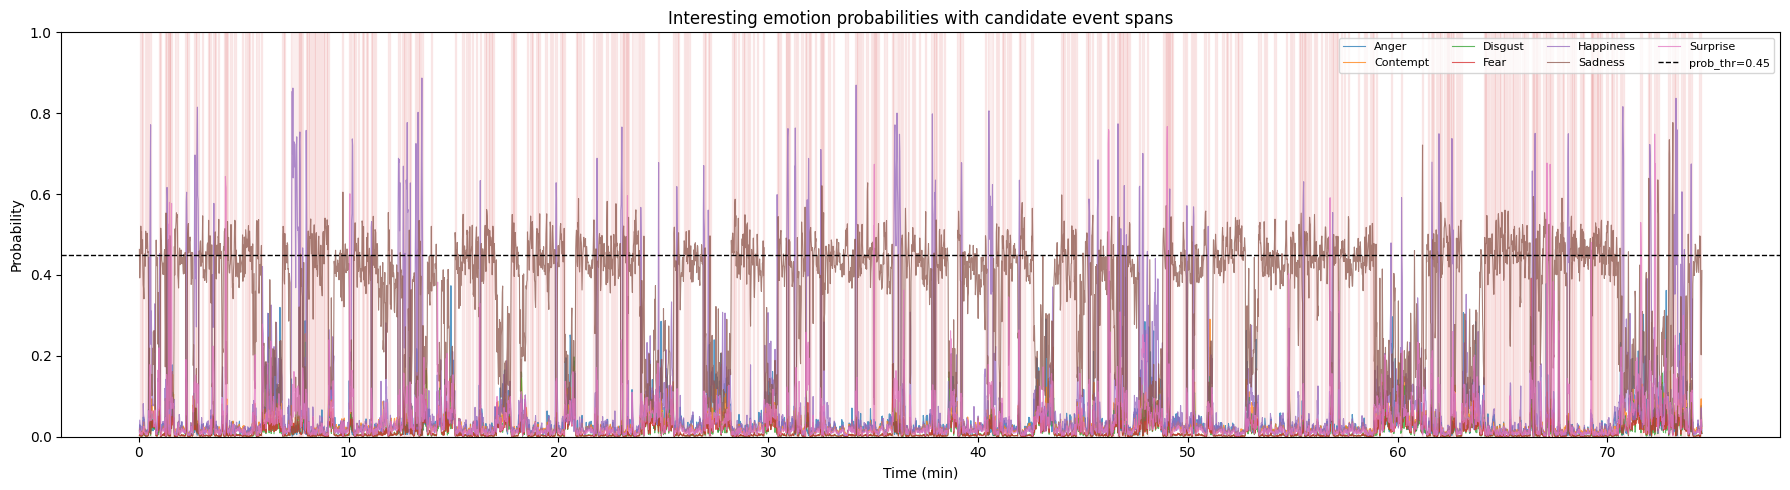

In [33]:
fig, ax = plt.subplots(figsize=(18, 5))

for class_idx, label in zip(interesting_idx, interesting_labels):
    ax.plot(frame_center_min, probs_np[:, class_idx], linewidth=0.8, alpha=0.75, label=label)

if len(events_df):
    for _, ev in events_df.iterrows():
        ax.axvspan(ev["start_min"], ev["end_min"], color="tab:red", alpha=0.08)

ax.axhline(PROB_THR, color="black", linestyle="--", linewidth=1, label=f"prob_thr={PROB_THR}")
ax.set_ylim(0, 1)
ax.set_xlabel("Time (min)")
ax.set_ylabel("Probability")
ax.set_title("Interesting emotion probabilities with candidate event spans")
ax.legend(loc="upper right", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


In [34]:
preview_events = []

for n, ev in events_df.head(20).iterrows():
    label = ev["label"].lower()
    preview_events.append({
        "event_id": f"emotion.categorical.v1.categorical.{n:06d}",
        "producer_id": "emotion.categorical.v1",
        "task": "emotion",
        "event_type": "categorical",
        "label": label,
        "start_sec": float(ev["start_sec"]),
        "end_sec": float(ev["end_sec"]),
        "duration_sec": float(ev["duration_sec"]),
        "source_track_ids": ("emotion.categorical.probabilities",),
        "score": float(ev["peak_prob"]),
        "score_name": "probability",
        "direction": None,
        "evidence": {
            "peak_time_sec": float(ev["peak_sec"]),
            "top_classes_at_peak": ev["top_classes_at_peak"],
            "interesting_mass_at_peak": float(ev["interesting_mass_at_peak"]),
            "margin_vs_background_at_peak": float(ev["peak_margin_vs_background"]),
        },
        "extra": {
            "frame_start": int(ev["frame_start"]),
            "frame_end": int(ev["frame_end"]),
            "prob_thr": PROB_THR,
            "margin_thr": MARGIN_THR,
            "min_duration_sec": MIN_DURATION_SEC,
            "merge_gap_sec": MERGE_GAP_SEC,
            "require_global_top1": REQUIRE_GLOBAL_TOP1,
        },
    })

display(pd.DataFrame(preview_events))


,event_id,producer_id,task,event_type,label,start_sec,end_sec,duration_sec,source_track_ids,score,score_name,direction,evidence,extra
0,emotion.categorical.v1.categorical.000000,emotion.categorical.v1,emotion,categorical,sadness,4.0,9.0,5.0,"(emotion.categorical.probabilities,)",0.520785,probability,None,"{'peak_time_sec': 5.5, 'top_classes_at_peak': ...","{'frame_start': 4, 'frame_end': 7, 'prob_thr':..."
1,emotion.categorical.v1.categorical.000001,emotion.categorical.v1,emotion,categorical,sadness,9.0,12.0,3.0,"(emotion.categorical.probabilities,)",0.486891,probability,None,"{'peak_time_sec': 10.5, 'top_classes_at_peak':...","{'frame_start': 9, 'frame_end': 10, 'prob_thr'..."
2,emotion.categorical.v1.categorical.000002,emotion.categorical.v1,emotion,categorical,sadness,18.0,21.0,3.0,"(emotion.categorical.probabilities,)",0.508288,probability,None,"{'peak_time_sec': 19.5, 'top_classes_at_peak':...","{'frame_start': 18, 'frame_end': 19, 'prob_thr..."
3,emotion.categorical.v1.categorical.000003,emotion.categorical.v1,emotion,categorical,sadness,22.0,25.0,3.0,"(emotion.categorical.probabilities,)",0.503252,probability,None,"{'peak_time_sec': 23.5, 'top_classes_at_peak':...","{'frame_start': 22, 'frame_end': 23, 'prob_thr..."
4,emotion.categorical.v1.categorical.000004,emotion.categorical.v1,emotion,categorical,happiness,30.0,35.0,5.0,"(emotion.categorical.probabilities,)",0.771472,probability,None,"{'peak_time_sec': 33.5, 'top_classes_at_peak':...","{'frame_start': 30, 'frame_end': 33, 'prob_thr..."
5,emotion.categorical.v1.categorical.000005,emotion.categorical.v1,emotion,categorical,happiness,58.0,61.0,3.0,"(emotion.categorical.probabilities,)",0.452773,probability,None,"{'peak_time_sec': 59.5, 'top_classes_at_peak':...","{'frame_start': 58, 'frame_end': 59, 'prob_thr..."
6,emotion.categorical.v1.categorical.000006,emotion.categorical.v1,emotion,categorical,sadness,61.0,64.0,3.0,"(emotion.categorical.probabilities,)",0.515607,probability,None,"{'peak_time_sec': 62.5, 'top_classes_at_peak':...","{'frame_start': 61, 'frame_end': 62, 'prob_thr..."
7,emotion.categorical.v1.categorical.000007,emotion.categorical.v1,emotion,categorical,sadness,76.0,79.0,3.0,"(emotion.categorical.probabilities,)",0.553267,probability,None,"{'peak_time_sec': 77.5, 'top_classes_at_peak':...","{'frame_start': 76, 'frame_end': 77, 'prob_thr..."
8,emotion.categorical.v1.categorical.000008,emotion.categorical.v1,emotion,categorical,happiness,78.0,83.0,5.0,"(emotion.categorical.probabilities,)",0.616507,probability,None,"{'peak_time_sec': 80.5, 'top_classes_at_peak':...","{'frame_start': 78, 'frame_end': 81, 'prob_thr..."
9,emotion.categorical.v1.categorical.000009,emotion.categorical.v1,emotion,categorical,surprise,84.0,89.0,5.0,"(emotion.categorical.probabilities,)",0.579609,probability,None,"{'peak_time_sec': 87.5, 'top_classes_at_peak':...","{'frame_start': 84, 'frame_end': 87, 'prob_thr..."
